In [1]:
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src" / "ml_textbook").exists():
        sys.path.insert(0, str(_p / "src"))
        break

# 04. モデルの評価と検証 — 「正しく測る」ことがモデル選びより重要

> 各章は **直感 → 最小限の数式 → scikit-learn 実装 → 可視化 → 実験 → 演習** の順。本文は日本語、コードは英語、数式に日本語を入れない。

## この章で分かること

- 回帰指標(MSE / RMSE / MAE / R²)と分類指標(accuracy / precision / recall / F1 / ROC-AUC / PR-AUC)の意味と使い分け
- **クラス不均衡** では accuracy が嘘をつくこと、PR 曲線が効くこと
- **閾値** はモデルと別に選べること(precision-recall トレードオフ)
- 確率の **較正 (calibration)** — 「0.8」が本当に 80% か
- **交差検証** の分布で見ること、**リーク** が CV を嘘にすること

> この章の主張: **「たくさんのモデルを試すより、正しく評価することの方が重要」。**
> 間違った評価は、間違ったモデルを自信満々で選ばせる。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

from ml_textbook import datasets, plotting, metrics
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
print("setup ok")

setup ok


## 1. 回帰の指標

- **MSE** $=\frac1n\sum (y-\hat y)^2$ : 大外しに敏感(二乗)。
- **RMSE** $=\sqrt{\text{MSE}}$ : 単位が $y$ と同じで読みやすい。
- **MAE** $=\frac1n\sum |y-\hat y|$ : 外れ値に頑健。
- **R²** $=1-\frac{\text{SS}_{res}}{\text{SS}_{tot}}$ : 「平均予測より何割よいか」。1 が完璧、0 が平均並み、負もありうる。

外れ値を 1 点入れると RMSE は跳ね、MAE はあまり動かないことを確認します。

In [3]:
rng = np.random.default_rng(0)
y_true = rng.normal(50, 10, 100)
y_pred = y_true + rng.normal(0, 3, 100)
base = metrics.regression_report(y_true, y_pred)

y_pred_out = y_pred.copy(); y_pred_out[0] += 60   # one big miss
withzout = metrics.regression_report(y_true, y_pred_out)

print(f"{'metric':6s} {'clean':>10s} {'+1 outlier':>12s}")
for k in ["MSE", "RMSE", "MAE", "R2"]:
    print(f"{k:6s} {base[k]:10.3f} {withzout[k]:12.3f}")
print("\nRMSE/MSE jump with the outlier; MAE barely moves.")

metric      clean   +1 outlier
MSE         8.243       46.053
RMSE        2.871        6.786
MAE         2.299        2.899
R2          0.911        0.503

RMSE/MSE jump with the outlier; MAE barely moves.


## 2. 分類の基礎 — 混同行列から全指標が出る

| | 予測 陰性 | 予測 陽性 |
|---|---|---|
| **実際 陰性** | TN | FP |
| **実際 陽性** | FN | TP |

- **precision** $=\frac{TP}{TP+FP}$ : 陽性と言った中の正解率(誤検知の少なさ)
- **recall** $=\frac{TP}{TP+FN}$ : 実際の陽性を取りこぼさない率(見逃しの少なさ)
- **F1** : precision と recall の調和平均

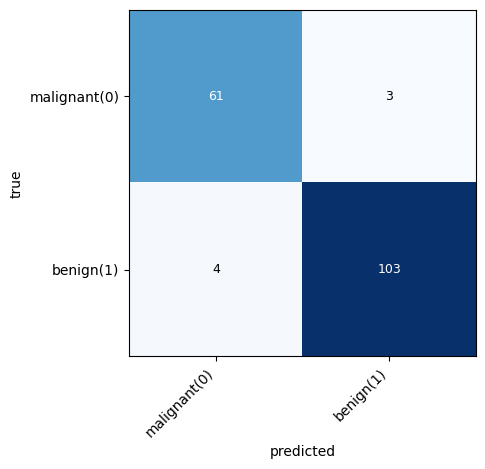

{'accuracy': 0.9590643274853801, 'precision': 0.9716981132075472, 'recall': 0.9626168224299065, 'f1': 0.9671361502347416}


In [4]:
bc = datasets.load_breast_cancer_dataset()
Xtr, Xte, ytr, yte = train_test_split(bc.data, bc.target, test_size=0.3, random_state=0, stratify=bc.target)
from sklearn.linear_model import LogisticRegression
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xtr, ytr)
pred = clf.predict(Xte)

cm = metrics.confusion_matrix(yte, pred, n_classes=2)
ax = plotting.plot_confusion_matrix(cm, class_names=["malignant(0)", "benign(1)"])
plt.show()
print(metrics.classification_report(yte, pred))

## 3. クラス不均衡 — accuracy の罠

陽性が 5% しかないデータでは、「**常に陰性**」と答えるだけで accuracy 95% です。
accuracy はこの「何もしないベースライン」を超えられているか分かりません。precision/recall を見ます。

In [5]:
Xi, yi = datasets.make_imbalanced_classification_dataset(n=4000, weights=(0.95, 0.05), seed=0)
print("positive rate:", round(float(yi.mean()), 3))
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, yi, test_size=0.3, random_state=0, stratify=yi)

clf_i = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xi_tr, yi_tr)
pred_i = clf_i.predict(Xi_te)

dummy_acc = 1 - yi_te.mean()  # always-negative baseline
print(f"always-negative accuracy : {dummy_acc:.3f}")
print(f"model accuracy           : {metrics.accuracy(yi_te, pred_i):.3f}")
print(f"model precision          : {metrics.precision(yi_te, pred_i):.3f}")
print(f"model recall             : {metrics.recall(yi_te, pred_i):.3f}")
print("Accuracy looks great but is barely above doing nothing — recall is what matters here.")

positive rate: 0.054
always-negative accuracy : 0.946
model accuracy           : 0.993
model precision          : 0.983
model recall             : 0.892
Accuracy looks great but is barely above doing nothing — recall is what matters here.


## 4. ROC 曲線と PR 曲線

確率出力をいろいろな閾値で切ると、(FPR, TPR) の軌跡が **ROC 曲線**、(recall, precision) の軌跡が **PR 曲線**。

- **ROC-AUC**: 0.5 がランダム、1.0 が完璧。
- **PR-AUC (Average Precision)**: 陽性が稀なときに有用。ROC は大量の真陰性に「薄められて」楽観的になりがち。

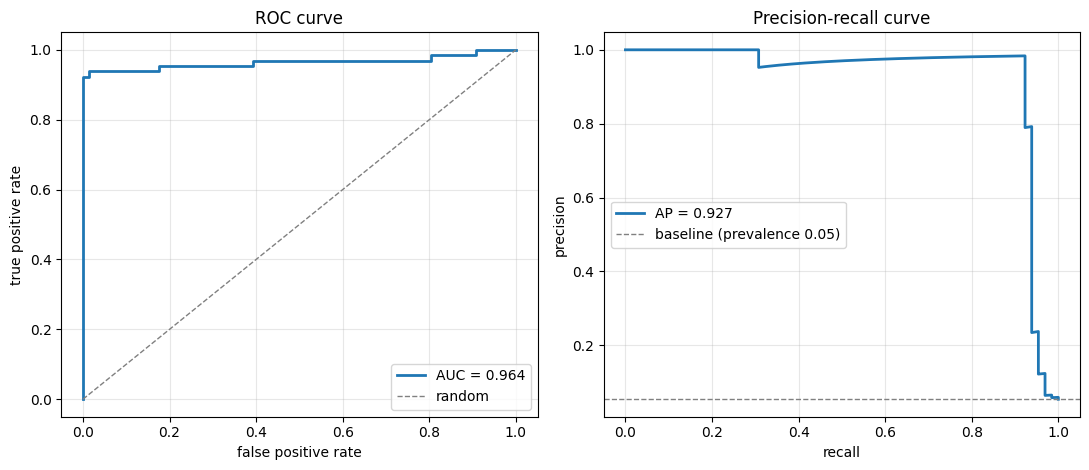

ROC-AUC = 0.964   PR-AUC = 0.927
On a 5% positive rate, ROC-AUC looks rosy while PR-AUC tells the harder truth.


In [6]:
score_i = clf_i.predict_proba(Xi_te)[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
plotting.plot_roc_curve(yi_te, score_i, ax=axes[0])
plotting.plot_precision_recall_curve(yi_te, score_i, ax=axes[1])
plt.tight_layout(); plt.show()
print(f"ROC-AUC = {metrics.roc_auc(yi_te, score_i):.3f}   PR-AUC = {metrics.pr_auc(yi_te, score_i):.3f}")
print("On a 5% positive rate, ROC-AUC looks rosy while PR-AUC tells the harder truth.")

## 5. 閾値チューニング

既定の 0.5 は最適とは限りません。見逃しが致命的なら **recall を上げる**(閾値を下げる)、
誤検知のコストが高いなら **precision を上げる**(閾値を上げる)。下のスライダー(静的 HTML 可)で動かせます。

In [7]:
plotting.plotly_threshold_explorer(yi_te, score_i, n_thresholds=19).show()

In [8]:
# Pick the lowest threshold that achieves at least 80% precision, then report recall there.
from sklearn.metrics import precision_recall_curve
prec, rec, thr = precision_recall_curve(yi_te, score_i)
ok = np.where(prec[:-1] >= 0.80)[0]
if len(ok):
    t = thr[ok[0]]
    pred_t = (score_i >= t).astype(int)
    print(f"threshold for >=80% precision: {t:.3f}")
    print(f"  precision={metrics.precision(yi_te, pred_t):.3f}  recall={metrics.recall(yi_te, pred_t):.3f}")

threshold for >=80% precision: 0.101
  precision=0.800  recall=0.923


## 6. 確率の較正 (calibration)

「陽性確率 0.8」と言うなら、そう言った中の約 80% が本当に陽性であってほしい。これが **較正**。
ロジスティック回帰はよく較正され、Naive Bayes は両端に張り付いて過信しがちです。
**ECE**(期待較正誤差)で数値化します。

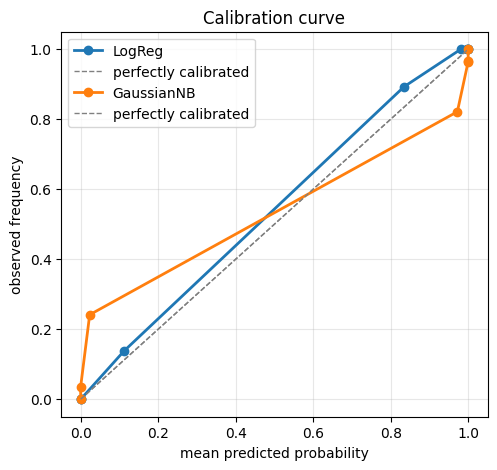

ECE  LogReg   = 0.022
ECE  GaussianNB = 0.071  (higher = worse calibrated)


In [9]:
from sklearn.naive_bayes import GaussianNB

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(bc.data, bc.target, test_size=0.4, random_state=0, stratify=bc.target)
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xb_tr, yb_tr)
nb = GaussianNB().fit(Xb_tr, yb_tr)
p_logit = logit.predict_proba(Xb_te)[:, 1]
p_nb = nb.predict_proba(Xb_te)[:, 1]

fig, ax = plt.subplots(figsize=(5.5, 5))
plotting.plot_calibration_curve(yb_te, p_logit, ax=ax, n_bins=8, label="LogReg")
plotting.plot_calibration_curve(yb_te, p_nb, ax=ax, n_bins=8, label="GaussianNB")
plt.show()
print(f"ECE  LogReg   = {metrics.expected_calibration_error(yb_te, p_logit):.3f}")
print(f"ECE  GaussianNB = {metrics.expected_calibration_error(yb_te, p_nb):.3f}  (higher = worse calibrated)")

## 7. 交差検証は「点」でなく「分布」で見る

1 回の train/test 分割は運に左右されます。**k-fold 交差検証** で複数の成績を取り、その **散らばり** まで見ます。

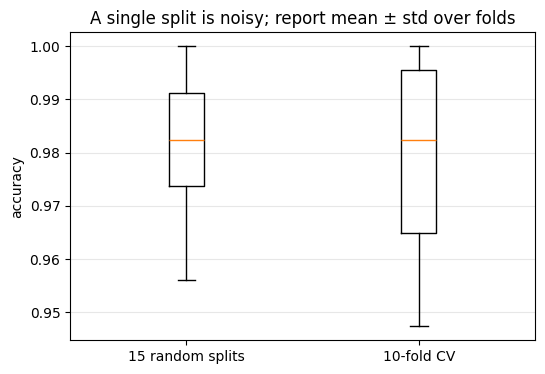

10-fold CV: 0.977 +/- 0.019


In [10]:
from sklearn.model_selection import StratifiedKFold

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
cv_scores = cross_val_score(pipe, bc.data, bc.target, cv=StratifiedKFold(10, shuffle=True, random_state=0))
single = []
for s in range(15):
    Xtr2, Xte2, ytr2, yte2 = train_test_split(bc.data, bc.target, test_size=0.2, random_state=s, stratify=bc.target)
    single.append(make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xtr2, ytr2).score(Xte2, yte2))

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([single, cv_scores], tick_labels=["15 random splits", "10-fold CV"])
ax.set_ylabel("accuracy"); ax.set_title("A single split is noisy; report mean ± std over folds")
ax.grid(alpha=0.3, axis="y"); plt.show()
print(f"10-fold CV: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

## 8. リークが交差検証を嘘にする(最重要)

高次元データで、**特徴選択を「全データ」で行ってから** CV すると、実際には信号が無いのに高スコアが出ます。
下は **完全なノイズ**(ラベルと無関係な 2000 特徴)。正しい手順なら CV ≈ 0.5(ランダム)になるはずです。

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif

rng = np.random.default_rng(0)
Xnoise = rng.standard_normal((120, 2000))   # pure noise
ynoise = rng.integers(0, 2, size=120)        # random labels — NO signal exists

# WRONG: choose the 20 "best" features using ALL labels, then cross-validate.
Xsel = SelectKBest(f_classif, k=20).fit_transform(Xnoise, ynoise)
wrong = cross_val_score(LogisticRegression(max_iter=2000), Xsel, ynoise, cv=5).mean()

# RIGHT: selection happens INSIDE the pipeline, refit on each training fold.
right_pipe = make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=2000))
right = cross_val_score(right_pipe, Xnoise, ynoise, cv=5).mean()

print(f"select-then-CV (LEAKY) : {wrong:.3f}   <- looks predictive on pure noise!")
print(f"selection inside pipe   : {right:.3f}   <- correctly ~0.5 (chance)")

select-then-CV (LEAKY) : 0.783   <- looks predictive on pure noise!
selection inside pipe   : 0.433   <- correctly ~0.5 (chance)


## 9. モデル選択は CV で行い、テストは最後に一度だけ

複数モデルを **交差検証** で比べ、勝者を選び、**取っておいたテスト**で最後に一度だけ確認します。
テストを見ながらモデルを選ぶと、テストへの過学習(=もう一つのリーク)になります。

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

X_tr, X_te, y_tr, y_te = train_test_split(bc.data, bc.target, test_size=0.25, random_state=0, stratify=bc.target)
candidates = {
    "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC()),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=0),
}
cv_means = {name: cross_val_score(m, X_tr, y_tr, cv=5).mean() for name, m in candidates.items()}
best = max(cv_means, key=cv_means.get)
for name, s in cv_means.items():
    print(f"{name:14s} CV acc = {s:.3f}" + ("   <- selected" if name == best else ""))
final = candidates[best].fit(X_tr, y_tr)
print(f"\n{best} held-out TEST accuracy (touched once): {final.score(X_te, y_te):.3f}")

LogReg         CV acc = 0.974
SVM (RBF)      CV acc = 0.986   <- selected
RandomForest   CV acc = 0.955

SVM (RBF) held-out TEST accuracy (touched once): 0.958


## 10. まとめ

- 指標は問題に合わせる。回帰は外れ値の扱いで MAE/RMSE を選ぶ。分類は **不均衡なら accuracy を信じない**。
- ROC-AUC は全体の順位力、**PR-AUC は稀な陽性**に強い。閾値はモデルと独立に選べる。
- 確率は **較正** を確認(ECE)。意思決定に確率を使うなら必須。
- 評価は **CV の分布** で。単一分割は運。
- **リーク**(全データでの前処理・特徴選択、テストを見たモデル選択)が最大の敵。`Pipeline` + CV で防ぐ。
- workflow: CV で選ぶ → テストは最後に一度だけ。

## 11. Exercises

1. 不均衡比を 0.01 にして、ROC-AUC と PR-AUC のどちらがより悪化するか観察せよ。
2. 閾値スライダーで F1 が最大になる閾値を読み、`f1` を 0.5 のときと比べよ。
3. GaussianNB を `CalibratedClassifierCV` で包むと ECE がどれだけ下がるか測れ。
4. 特徴選択リークのデモで、特徴数 2000 を 200 / 5000 に変えると leaky スコアはどう動くか。
5. (発展)モデル選択で、CV ではなくテストで選ぶと何が起きるか。複数 seed で「テスト最良」が安定しないことを示せ。

## 12. Common Mistakes

- **不均衡で accuracy を報告。** 常に陰性ベースラインと比べる。precision/recall/PR-AUC を見る。
- **閾値 0.5 を固定。** コストに応じて選ぶ。
- **前処理・特徴選択を CV の外でやる。** リーク。すべて `Pipeline` の中へ。
- **テストを何度も見る。** テストへの過学習。最後に一度だけ。
- **確率をそのまま信じる。** 較正していないモデルの確率は過信/過小になりうる。